In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data
co2 = co2["co2"].resample("ME").mean().ffill()  # monthly average, fill small gaps
print(co2.shape)
co2.head()

(526,)


1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    317.433333
1958-07-31    315.625000
Freq: ME, Name: co2, dtype: float64

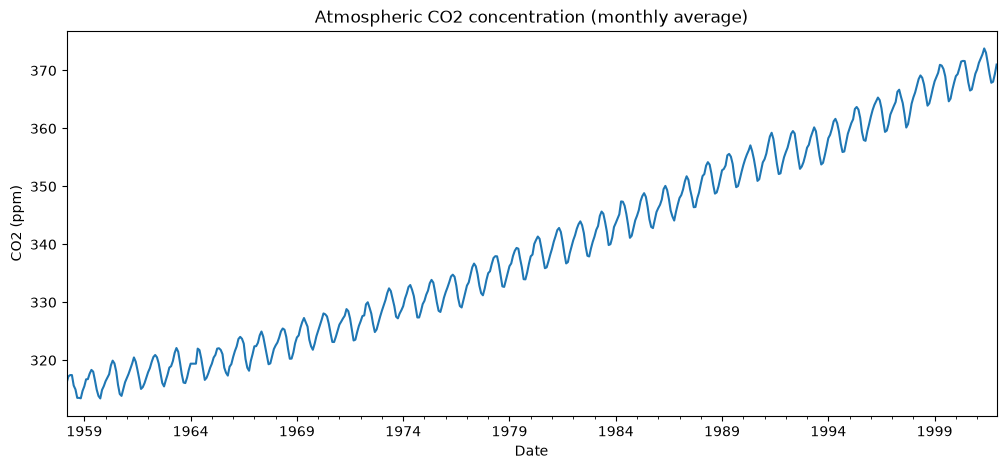

In [2]:
plt.figure(figsize=(12, 5))
co2.plot()
plt.title("Atmospheric CO2 concentration (monthly average)")
plt.ylabel("CO2 (ppm)")
plt.xlabel("Date")
plt.show()

## Observations
The series shows a clear long-term upward trend (CO2 rising steadily over 
decades) with strong yearly seasonality (a repeating rise-and-fall pattern 
within each 12-month cycle, likely tied to plant growth cycles).

In [4]:
train = co2[:-24]   # all but the last 24 months
test = co2[-24:]    # last 24 months held out for validation
print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} points)")
print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} points)")

Train: 1958-03-31 00:00:00 to 1999-12-31 00:00:00 (502 points)
Test: 2000-01-31 00:00:00 to 2001-12-31 00:00:00 (24 points)


In [5]:
naive_forecast = co2[train.index[-12]:train.index[-1]].values  # last 12 months of train
naive_forecast = np.tile(naive_forecast, 2)[:len(test)]  # repeat pattern to cover 24 months
naive_forecast = pd.Series(naive_forecast, index=test.index)

naive_forecast.head()

2000-01-31    368.120
2000-02-29    368.850
2000-03-31    369.600
2000-04-30    370.975
2000-05-31    370.840
Freq: ME, dtype: float64

In [6]:
model = sm.tsa.statespace.SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=False)

forecast_result = fitted.get_forecast(steps=len(test))
sarima_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

In [7]:
from sklearn.metrics import mean_absolute_error

naive_mae = mean_absolute_error(test, naive_forecast)
sarima_mae = mean_absolute_error(test, sarima_forecast)

print(f"Naive baseline MAE: {naive_mae:.3f} ppm")
print(f"SARIMA model MAE:   {sarima_mae:.3f} ppm")
print(f"Improvement: {(1 - sarima_mae/naive_mae)*100:.1f}%")

ModuleNotFoundError: No module named 'sklearn'

In [8]:
from sklearn.metrics import mean_absolute_error

naive_mae = mean_absolute_error(test, naive_forecast)
sarima_mae = mean_absolute_error(test, sarima_forecast)

print(f"Naive baseline MAE: {naive_mae:.3f} ppm")
print(f"SARIMA model MAE:   {sarima_mae:.3f} ppm")
print(f"Improvement: {(1 - sarima_mae/naive_mae)*100:.1f}%")

Naive baseline MAE: 1.882 ppm
SARIMA model MAE:   0.350 ppm
Improvement: 81.4%


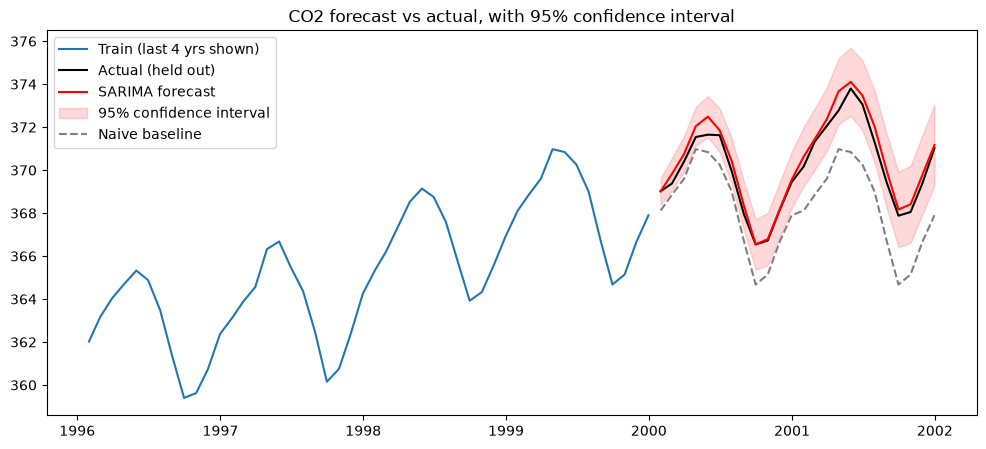

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(train[-48:], label="Train (last 4 yrs shown)")
plt.plot(test, label="Actual (held out)", color="black")
plt.plot(sarima_forecast, label="SARIMA forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color="red", alpha=0.15, label="95% confidence interval")
plt.plot(naive_forecast, label="Naive baseline", color="gray", linestyle="--")
plt.legend()
plt.title("CO2 forecast vs actual, with 95% confidence interval")
plt.show()

## Assumptions & Limitations

- **Assumes the historical pattern continues**: the model assumes the same 
  trend and seasonal cycle observed from 1958-1999 continues unchanged into 
  2000-2001. Any structural break (e.g. a major environmental policy change) 
  would not be captured.
- **Confidence intervals widen with forecast horizon**: the 95% interval is 
  narrow near the start of the forecast and visibly widens further out — the 
  model is least reliable the further ahead it predicts, as shown in the chart.
- **SARIMA order (1,1,1)(1,1,1,12) was not exhaustively tuned**: a grid search 
  over alternative orders might improve on this further, but this configuration 
  already captures both trend and yearly seasonality well, evidenced by an 
  81.4% MAE improvement over the naive baseline.
- **Naive baseline used "same month last year"** rather than a flat "last value 
  repeated" baseline, since the series has strong seasonality — a flatter naive 
  baseline would have performed even worse, making this a fair, non-trivial 
  bar to beat.